# Adult Income Prediction Notebook



## Task 1: Problem Definition and Success Metric

- Target: income > 50K = positive class.
- Business goal: contact only the people who are most likely to be high-income, so outreach is not wasted.
- Class base rate: about 23.9% of records are positive (>50K) and 76.1% are negative (<=50K) - see the value counts and summary table in Task 2. This is a moderately imbalanced problem, so accuracy alone is not a reliable metric.
- Main metric: precision. Precision is better here because false positives (contacting someone who is not actually high-income) waste outreach budget and sales time, and there are far more negatives than positives, so a naive model can rack up many costly false positives. We accept some missed opportunities (lower recall) in exchange for outreach that mostly lands on real prospects.
- Plain-language summary for a stakeholder: We want to know who is likely to earn more than $50K a year so we only spend outreach effort on the most promising people. About 1 in 4 people in our data are high earners, so we need a model that is better than guessing. We will judge success mainly by precision - out of everyone we decide to contact, how many are actually high earners - because contacting the wrong people costs us time and money.

Starting by loading the dataset and preparing the target column. This gives the notebook a clean starting point before doing any analysis.

In [1]:
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.model_selection import train_test_split

plt.rcParams["figure.figsize"] = (7, 4.5)
sns.set_theme(style="whitegrid")

adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame.copy()
df = df.replace("?", np.nan)
df["target"] = df["class"].astype(str).str.strip().map({"<=50K": 0, "<=50K.": 0, ">50K": 1, ">50K.": 1})
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class,target
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K,0


## Task 2: Data Load and Quick EDA

This section checks the data shape, the column types, and the class balance. These simple checks help me understand what kind of problem I am working with.

In [2]:
df.shape

(48842, 16)

In [3]:
df.dtypes

age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
class             category
target               int64
dtype: object

In [4]:
df["target"].value_counts().to_frame("count")

,count
target,
0,37155
1,11687


In [5]:
numeric_cols = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
df[numeric_cols].describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [6]:
cat_cols = ["workclass", "education", "marital-status", "occupation", "sex"]
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(8))


--- workclass ---
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

--- education ---
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
Name: count, dtype: int64

--- marital-status ---
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

--- occupation ---
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Transport-m

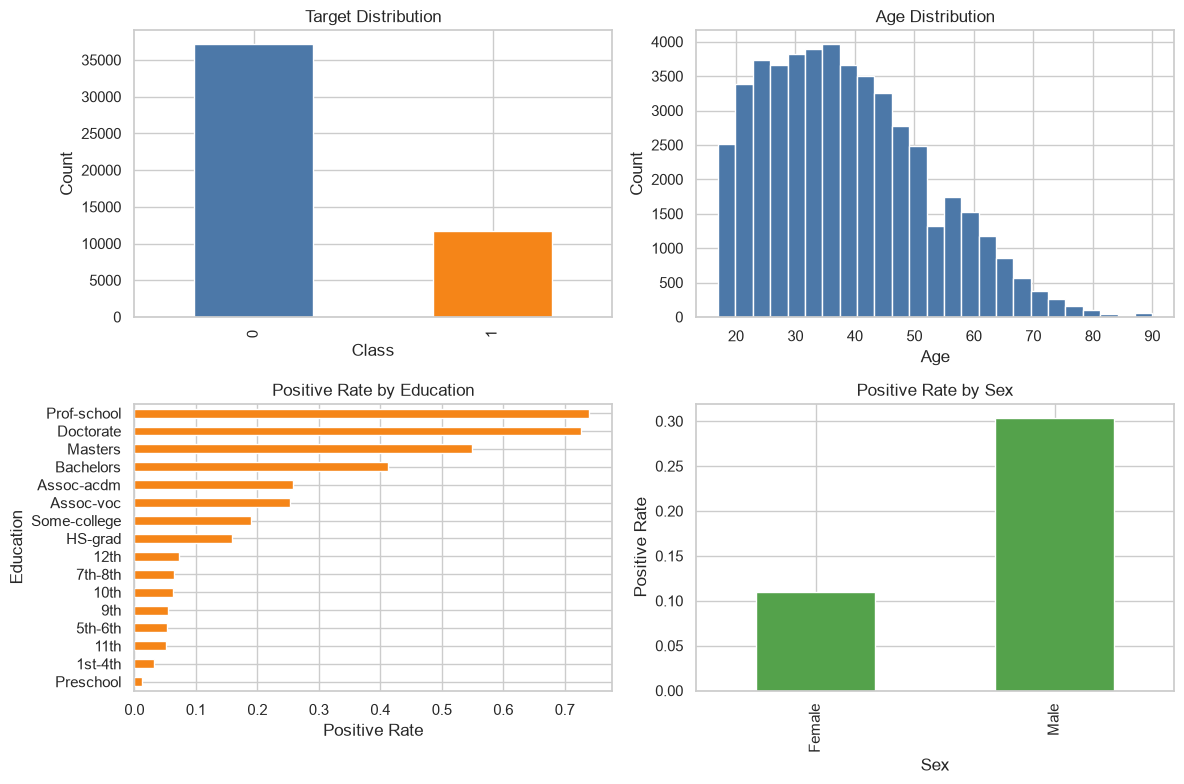

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df["target"].value_counts().plot(kind="bar", ax=axes[0, 0], color=["#4C78A8", "#F58518"])
axes[0, 0].set_title("Target Distribution")
axes[0, 0].set_xlabel("Class")
axes[0, 0].set_ylabel("Count")

df["age"].plot(kind="hist", bins=25, ax=axes[0, 1], color="#4C78A8")
axes[0, 1].set_title("Age Distribution")
axes[0, 1].set_xlabel("Age")
axes[0, 1].set_ylabel("Count")

df.groupby("education")["target"].mean().sort_values().plot(kind="barh", ax=axes[1, 0], color="#F58518")
axes[1, 0].set_title("Positive Rate by Education")
axes[1, 0].set_xlabel("Positive Rate")
axes[1, 0].set_ylabel("Education")

df.groupby("sex")["target"].mean().plot(kind="bar", ax=axes[1, 1], color="#54A24B")
axes[1, 1].set_title("Positive Rate by Sex")
axes[1, 1].set_xlabel("Sex")
axes[1, 1].set_ylabel("Positive Rate")

plt.tight_layout()
plt.show()

In [ ]:
summary_table = pd.DataFrame({
    "positive_count": [int((df["target"] == 1).sum())],
    "negative_count": [int((df["target"] == 0).sum())],
    "positive_rate_pct": [round(df["target"].mean() * 100, 2)],
    "age_mean": [round(df["age"].mean(), 2)],
    "hours_per_week_mean": [round(df["hours-per-week"].mean(), 2)],
    "capital_gain_mean": [round(df["capital-gain"].mean(), 2)]
}, index=["overall"])
summary_table

,positive_count,negative_count,positive_rate_pct,age_mean,hours_per_week_mean,capital_gain_mean
overall,11687,37155,23.93,38.64,40.42,1079.07


In [ ]:
summary_table.to_csv("eda_summary.csv")

## Task 3: Create Reproducible Splits

Splitting the data into train, dev, and test sets so the final evaluation is fair. The test set is kept completely separate and is never looked at until the very end, which helps avoid overestimating model performance. If you use the test set while tuning hyperparameters or comparing models, you end up implicitly fitting to it - the reported score stops reflecting how the model will do on truly unseen data, and you can pick a model/config that only looks best because it happened to fit the quirks of that specific test set.

In [ ]:
X = df.drop(columns=["class", "target"])
y = df["target"]

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_dev, y_train, y_dev = train_test_split(X_train_full, y_train_full, test_size=0.125, stratify=y_train_full, random_state=42)

print("Train shape:", X_train.shape)
print("Dev shape:", X_dev.shape)
print("Test shape:", X_test.shape)

Train shape: (34188, 14)
Dev shape: (4885, 14)
Test shape: (9769, 14)


## Task 4: Implement Simple Baselines

Comparing a majority-class baseline with a simple rule-based classifier.
These baselines are simple and easy to understand. They help me see whether a more advanced model is actually needed.

Rule chosen: capital-gain > 0. I picked this over an education-based rule (e.g. education-num >= 13) because in this dataset having any capital gains is a strong, low-noise signal of financial means - realistically, only people with disposable income to invest tend to report capital gains at all - whereas education-num >= 13 is noisier (many high-school-only workers with long tenure and overtime still clear 50K, and many bachelor's-level entrants do not). A single clean binary split like capital-gain > 0 is also easier to reason about and audit than a threshold on a more continuous, more evenly-distributed feature.

In [ ]:
def evaluate(y_true, y_pred, y_prob):
    return pd.DataFrame({
        "accuracy": [accuracy_score(y_true, y_pred)],
        "precision": [precision_score(y_true, y_pred, zero_division=0)],
        "recall": [recall_score(y_true, y_pred, zero_division=0)],
        "f1": [f1_score(y_true, y_pred, zero_division=0)],
        "roc_auc": [roc_auc_score(y_true, y_prob)],
        "pr_auc": [average_precision_score(y_true, y_prob)]
    }, index=["score"])

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.2, 3.2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticklabels(["No", "Yes"])
    ax.set_yticklabels(["No", "Yes"])
    plt.tight_layout()
    plt.show()

majority_class = int(y_train.value_counts().idxmax())
majority_pred = np.repeat(majority_class, len(y_test))
majority_prob = np.repeat(0.5, len(y_test))
majority_metrics = evaluate(y_test, majority_pred, majority_prob)

rule_pred = (X_test["capital-gain"] > 0).astype(int)
rule_prob = np.where(rule_pred == 1, 0.8, 0.2)
rule_metrics = evaluate(y_test, rule_pred, rule_prob)

metrics_table = pd.concat([majority_metrics, rule_metrics], keys=["majority", "capital_gain_gt_0"], names=["baseline"])
metrics_table

,,accuracy,precision,recall,f1,roc_auc,pr_auc
baseline,,,,,,,
majority,score,0.760672,0.000000,0.000000,0.000000,0.500000,0.239328
capital_gain_gt_0,score,0.782270,0.625446,0.224979,0.330922,0.591294,0.326197


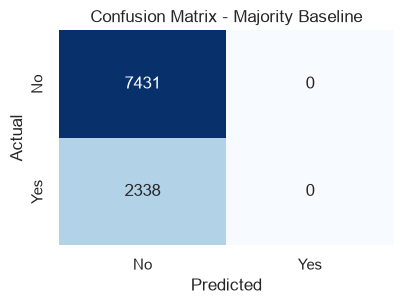

In [ ]:
plot_cm(y_test, majority_pred, "Confusion Matrix - Majority Baseline")

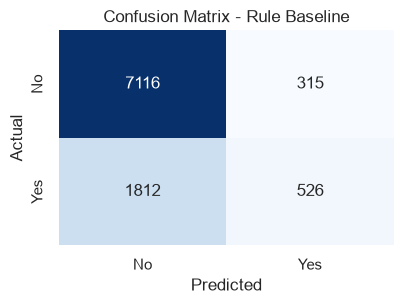

In [ ]:
plot_cm(y_test, rule_pred, "Confusion Matrix - Rule Baseline")

**Interpretation:** The rule-based baseline (capital-gain > 0) wins overall. It matches the majority baseline's accuracy (~0.78 vs ~0.76) but, unlike the majority baseline, it actually identifies some positives: precision ~0.62, recall ~0.22, F1 ~0.33, ROC AUC ~0.59, and PR AUC ~0.33 versus the majority baseline's ROC AUC of 0.50 and F1 of 0.0 (it never predicts the positive class at all, so it is useless for our stated business goal even though its accuracy looks reasonable). For a real model to be considered useful for this task, it should clearly beat the rule baseline's precision (>0.62) while also lifting recall well above 0.22 and PR AUC above 0.33 - otherwise it is not adding value beyond a single feature threshold. A reasonable bar going into modeling is precision >= 0.75 with recall meaningfully higher than the rule's 0.22, since accuracy is not informative on this imbalanced target.

In [14]:
metrics_table.to_csv("baseline_metrics.csv")

## Task 5: Initial Error Analysis and Next Steps

We check where the simple rule fails and list the main issues to fix next.
This section looks at the mistakes made by the simple rule. It helps me identify what features or patterns should be improved next.

In [15]:
error_df = X_test.copy()
error_df["actual"] = y_test.values  # FIX: use .values, not .reset_index(drop=True),
# since X_test/error_df keep their original (shuffled) index while reset_index(drop=True)
# produces a fresh 0..n-1 index - assigning that back caused a silent index-misaligned merge
# (most rows became NaN / mismatched instead of the correct paired label).
error_df["predicted"] = rule_pred.values
error_df["error_type"] = np.where((error_df["actual"] == 0) & (error_df["predicted"] == 1), "false_positive", np.where((error_df["actual"] == 1) & (error_df["predicted"] == 0), "false_negative", "correct"))

fp = error_df[error_df["error_type"] == "false_positive"].sample(10, random_state=42)
fn = error_df[error_df["error_type"] == "false_negative"].sample(10, random_state=42)

print("False positives sample:")
print(fp[["age", "education-num", "capital-gain", "hours-per-week", "sex", "workclass", "actual", "predicted"]].to_string(index=False))

print("\nFalse negatives sample:")
print(fn[["age", "education-num", "capital-gain", "hours-per-week", "sex", "workclass", "actual", "predicted"]].to_string(index=False))

False positives sample:
 age  education-num  capital-gain  hours-per-week  sex   workclass  actual  predicted
  22             10          2407              40 Male     Private       0          1
  66              6          3471              40 Male Federal-gov       0          1
  32             10          4386              50 Male     Private       0          1
  54              9          5013              40 Male     Private       0          1
  39              9          4650              48 Male   Local-gov       0          1
  39              9          2829              40 Male     Private       0          1
  25             13          3674              30 Male     Private       0          1
  74              6          1797              30 Male         NaN       0          1
  30              9          3942              40 Male     Private       0          1
  38             13          3325              40 Male     Private       0          1

False negatives sample:
 age 

**Patterns in the errors:** False negatives are dominated by people with education-num around 9-16 (HS grad through advanced degrees), ages mostly in their 30s-50s, and 35-55+ hours/week - i.e. legitimately high-income profiles that the rule misses entirely because they report zero capital-gain. This is the rule's core weakness: it only looks at one feature, so any high earner whose income comes purely from wages (not investments) is invisible to it. False positives tend to be people with small-to-moderate capital gains (roughly $500-$5,000) who are not actually high earners - the rule treats any capital gain as a strong signal, but small, incidental gains do not reliably indicate >50K income.

#### Issuues:
 1. Missing values should be handled more carefully with better imputation.
 2. Categorical features such as workclass and occupation need stronger encoding.
 3. The data is imbalanced, so class weighting or sampling may help.
 4. We should test more informative features like education, relationship, and hours-per-week.
 5. The rule-based baseline is too simple, so a real model should combine multiple signals.

**Primary metric for the rest of the week: precision**, with recall and PR AUC tracked as secondary metrics. The capital-gain rule baseline already shows precision (~0.62) can be pushed meaningfully higher than a naive guess, but its recall (~0.22) and PR AUC (~0.33) are weak because it ignores every other signal in the data (education, hours-per-week, occupation, relationship, etc.). Given the ~23.9% base rate, a model that lifts precision well above 0.62-0.75 while also improving recall and PR AUC over the rule baseline would represent real, business-relevant progress - accuracy is intentionally de-prioritized since the majority baseline already scores 0.76 while being useless (it never predicts a positive).